# Libraries and Data

In [1]:
# Standard Libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
from sklearn.model_selection import ParameterGrid

# Darts functions
from darts.timeseries import TimeSeries
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.dataprocessing.transformers import Scaler
from darts.models import TFTModel

In [2]:
# Loading the Data and Setting the Index
# Hourly electricity consumption data
df = pd.read_csv("electricity.csv", index_col = "ds", parse_dates = True)
df.head()

,unique_id,y,Exogenous1,Exogenous2
ds,,,,
2016-10-22 00:00:00,BE,70.00,49593.0,57253.0
2016-10-22 01:00:00,BE,37.10,46073.0,51887.0
2016-10-22 02:00:00,BE,37.10,44927.0,51896.0
2016-10-22 03:00:00,BE,44.75,44483.0,48428.0
2016-10-22 04:00:00,BE,37.10,44338.0,46721.0


In [3]:
# Count the number of occurrences of each unique ID in the dataframe
df.unique_id.value_counts()

unique_id
BE     1680
DE     1680
FR     1680
NP     1680
PJM    1680
Name: count, dtype: int64

In [4]:
# Filter the dataframe to include only rows where the 'unique_id' is "DE"
df = df[df['unique_id'] == "DE"]
df.head()

,unique_id,y,Exogenous1,Exogenous2
ds,,,,
2017-10-22 00:00:00,DE,19.10,587.25,16972.75
2017-10-22 01:00:00,DE,19.03,623.00,16254.50
2017-10-22 02:00:00,DE,16.90,650.00,15940.25
2017-10-22 03:00:00,DE,12.98,687.25,15959.50
2017-10-22 04:00:00,DE,9.24,717.25,16071.50


In [5]:
# Information about the df
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1680 entries, 2017-10-22 00:00:00 to 2017-12-30 23:00:00
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unique_id   1680 non-null   object 
 1   y           1680 non-null   float64
 2   Exogenous1  1680 non-null   float64
 3   Exogenous2  1680 non-null   float64
dtypes: float64(3), object(1)
memory usage: 65.6+ KB


In [6]:
# Set the frequency of the time series data to hourly
df = df.asfreq("H")

# Exploratory Data Analysis

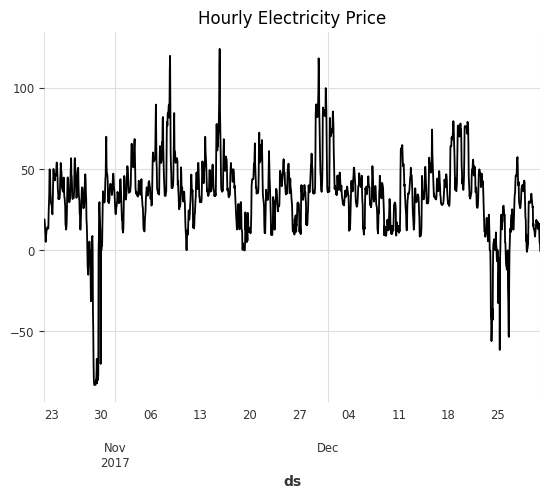

In [7]:
# Plot the hourly electricity price
df['y'].plot(title = 'Hourly Electricity Price')
plt.show()

`seasonal_decompose` - To decompose a time series into its constituent parts to better understand the underlying patterns.

components

- Trend: The overall direction of the series (increasing, decreasing, or stable).
- Seasonal: Repeating patterns at fixed intervals (e.g., daily, weekly, monthly).
- Residual: The remaining variation after removing trend and seasonal components.

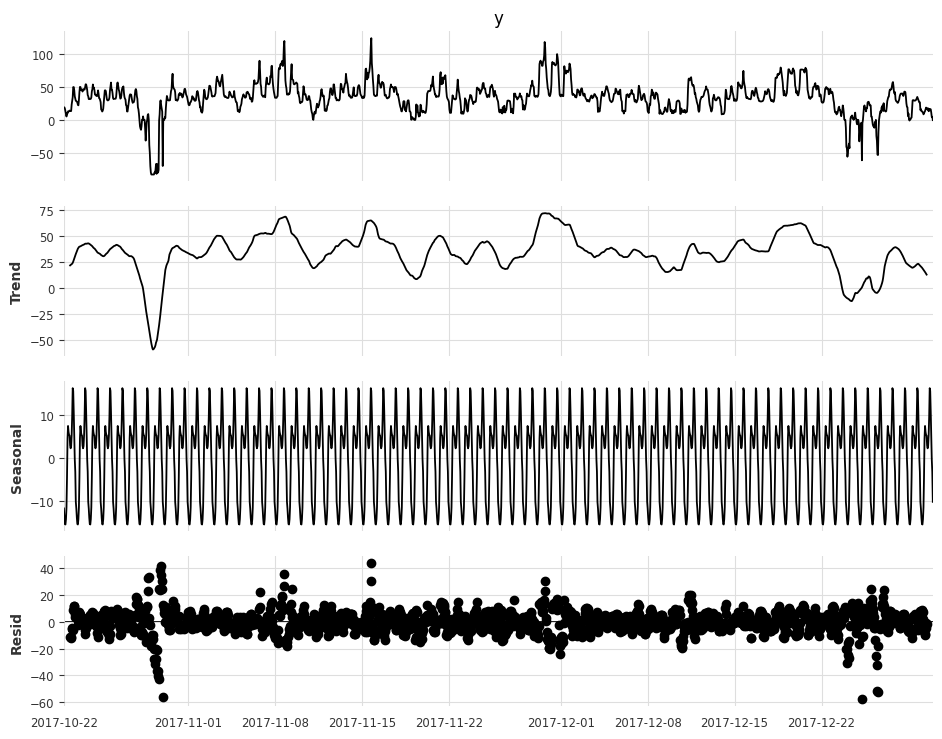

In [8]:
# Perform seasonal decomposition of the electricity price data using an additive model
decomposition = seasonal_decompose(df['y'],
                                   model = 'add',
                                   period = 24)

# Plot the decomposed components (trend, seasonal, and residual)
fig = decomposition.plot()
fig.set_size_inches(10,8)
plt.show()

Autocorrelation measures the correlation between a time series and a lagged version of itself.

Purpose: To identify patterns or repeating cycles in a time series dataset.

Interpretation:
- Values range from -1 to 1.
- 1 indicates perfect positive correlation.
- -1 indicates perfect negative correlation.
- 0 indicates no correlation.

ACF Plot:
- X-axis: Lag periods
- Y-axis: Correlation coefficient

Key Features:
- At lag 0, autocorrelation is always 1 (a series is perfectly correlated with itself).
- Significant spikes at certain lags indicate repeating patterns.


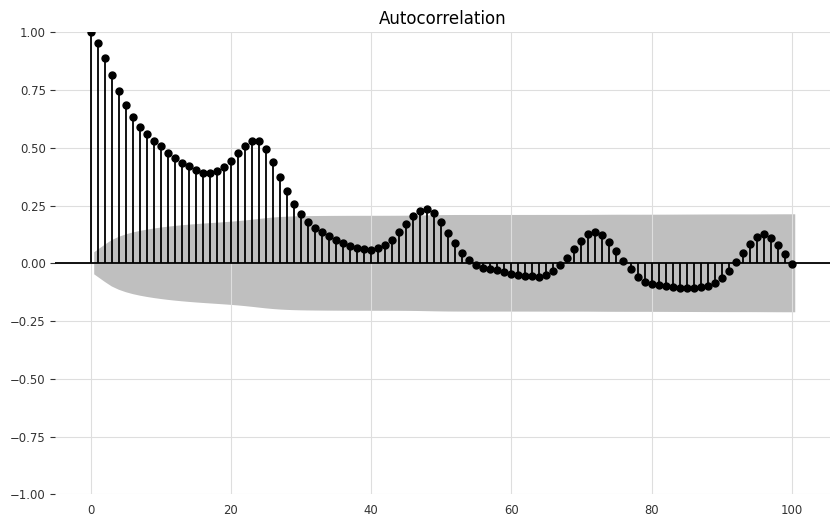

In [9]:
# Plot the autocorrelation function (ACF) for the time series data
fig, ax = plt.subplots(figsize = (10,6))
plot_acf(df['y'], lags = 100, ax = ax)  # Generate the ACF plot with 100 lags
plt.show()

PACF measures the correlation between a time series and its lag, after removing the effects of all shorter lags.

Purpose: To identify the direct relationship between an observation and its lag, without intermediate effects.

Main Difference between ACF and PACF:
- ACF: Measures overall correlation at each lag, including indirect effects.
- PACF: Measures direct correlation at each lag, excluding indirect effects.

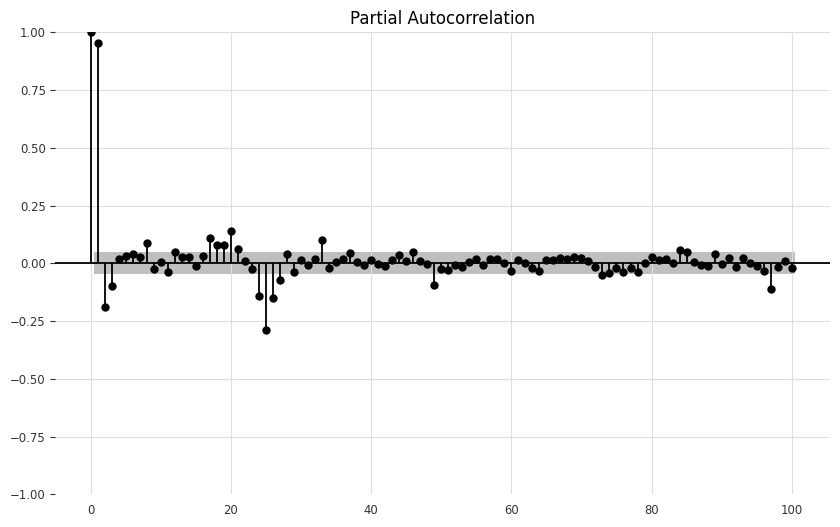

In [10]:
# Plot the partial autocorrelation function (PACF) for the time series data
fig, ax = plt.subplots(figsize = (10,6))
plot_pacf(df['y'], lags = 100, ax = ax)  # Generate the PACF plot with 100 lags
plt.show()

# Time series, Time, Static Variables

In [11]:
# Preparing the time series object
series = TimeSeries.from_dataframe(df, value_cols = "y",
                                  # statistatic_covariates=
                                  )
series.head()

<TimeSeries (DataArray) (ds: 5, component: 1, sample: 1)> Size: 40B
array([[[19.1 ]],

       [[19.03]],

       [[16.9 ]],

       [[12.98]],

       [[ 9.24]]])
Coordinates:
  * ds         (ds) datetime64[ns] 40B 2017-10-22 ... 2017-10-22T04:00:00
  * component  (component) <U1 4B 'y'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

In [12]:
# Time as an Encoder
def encode_year(idx): # bring the year to a small value
    return (idx.year-2000) / 50

# setup enconders dictionary
add_encoders = {
    "cyclic": {"future": ['hour','day','dayofweek','week','month']},
    "datetime_attribute": {"future": ['hour','day','dayofweek','week','month']},
    "position": {"past": ['relative' ], 'future': ['relative']},
    "custom": {'past': [encode_year], 'future': [encode_year]},
    "transformer": Scaler(),
    "tz": 'cet'
}

In [16]:
# Isolating the past covariates
X_past = df.iloc[:,2:]
past_coveriates = TimeSeries.from_dataframe(X_past)

In [22]:
# Future covariates
df_future = pd.read_csv("electricity-future.csv", index_col = "ds", parse_dates = True)
df_future = df_future[df_future['unique_id'] == "DE"]
df_future.iloc[:,1:].head()

,Exogenous1,Exogenous2
ds,,
2017-12-31 00:00:00,1392.25,14744.50
2017-12-31 01:00:00,1289.00,13906.00
2017-12-31 02:00:00,1206.25,13579.00
2017-12-31 03:00:00,1120.50,13302.75
2017-12-31 04:00:00,1053.25,13232.50


In [28]:
X_future = df_future.iloc[:,1:]
X = pd.concat([X_past,X_future], axis=0) # concatenates them along the rows (axis=0)
X

,Exogenous1,Exogenous2
ds,,
2017-10-22 00:00:00,587.25,16972.75
2017-10-22 01:00:00,623.00,16254.50
2017-10-22 02:00:00,650.00,15940.25
2017-10-22 03:00:00,687.25,15959.50
2017-10-22 04:00:00,717.25,16071.50
...,...,...
2017-12-31 19:00:00,1300.00,16601.00
2017-12-31 20:00:00,1261.00,15977.75
2017-12-31 21:00:00,1243.25,15715.00


In [29]:
future_covariates = TimeSeries.from_dataframe(X)

# Scaling

In [30]:
#importing the classes
scaler1 = Scaler()
scaler2 = Scaler()

# apply the scaler to the time series
y_transformed = scaler1.fit_transform(series)

# apply the scaler to the covariates
past_covariates_transformed = scaler2.fit_transform(past_coveriates)
future_covariates_transformed = scaler2.fit_transform(future_covariates)

# Parameters

In [38]:
forecasting_horizon = 24       # model predicts 24 hours in 1 go
input_chunk_length = 4*forecasting_horizon # model looks at the past 96 hours to make predictions
hidden_size = 16               # units in the LSTM layers (capacity to learn)
lstm_layers = 2                # learning hierarchical structures
number_of_attention_heads = 4  # model can focus on multiple parts of the input sequence at once
drop_out_rate = 0.1            # prevents overfitting, generalize better to new data
batch_size = 32                # model of samples before updating weights
number_of_epochs = 10          # 10 iterations, too much can cause overfitting
use_static_covariates = True

# TFT model

In [39]:
model = TFTModel(input_chunk_length = input_chunk_length,
                 output_chunk_length = forecasting_horizon,
                 hidden_size = hidden_size,
                 lstm_layers = lstm_layers,
                 num_attention_heads = number_of_attention_heads,
                 dropout = drop_out_rate,
                 batch_size = batch_size,
                 n_epochs = number_of_epochs,
                 add_encoders = add_encoders,
                 use_static_covariates = use_static_covariates,
                 pl_trainer_kwargs = {"accelerator":"cpu"}
)                 

In [41]:
model.fit(y_transformed,
          past_covariates=past_covariates_transformed,
          future_covariates=future_covariates_transformed)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 17.2 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 13.7 K | train
6  | static_context_grn                | _GatedResidualNetwork            | 1.1 K  | train
7  | static_context_hidden_encoder_grn | _GatedResidualNetwork 

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=10` reached.


TFTModel(output_chunk_shift=0, hidden_size=16, lstm_layers=2, num_attention_heads=4, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.1, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=False, loss_fn=None, likelihood=None, norm_type=LayerNorm, use_static_covariates=True, input_chunk_length=96, output_chunk_length=24, batch_size=32, n_epochs=10, add_encoders={'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'position': {'past': ['relative'], 'future': ['relative']}, 'custom': {'past': [<function encode_year at 0x000002B6EA0A34C0>], 'future': [<function encode_year at 0x000002B6EA0A34C0>]}, 'transformer': Scaler, 'tz': 'cet'}, pl_trainer_kwargs={'accelerator': 'cpu'})

# Cross-validation

In [49]:
# 8 to 10 runs
cv = model.historical_forecasts(
    series = y_transformed,
    past_covariates = past_covariates_transformed,
    future_covariates = future_covariates_transformed,
    forecast_horizon = forecasting_horizon,
    start = df.shape[0] - 10 * forecasting_horizon,
    retrain = True,
    stride = forecasting_horizon,
    last_points_only = False
)  

`enable_optimization=True` is ignored because `retrain` is not `False` or `0`. To hide this warning, set `show_warnings=False` or `enable_optimization=False`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 17.2 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 13.7 K | t

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=10` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 17.2 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 13.7 K | t

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=10` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 17.2 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 13.7 K | t

...

`Trainer.fit` stopped: `max_epochs=10` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 17.2 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 13.7 K | t

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=10` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 17.2 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 13.7 K | t

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=10` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [54]:
from sklearn.metrics import root_mean_squared_error

# Results
rmse_cv = []
for i in range(len(cv)):
    #outcome of the CV
    predictions = TimeSeries.pd_series(scaler1.inverse_transform(cv[i]))

    #actuals
    start = predictions.index.min()
    end = predictions.index.max()
    actuals = df.y[start:end]

    #compute error
    error_cv = root_mean_squared_error(actuals,predictions)
    rmse_cv.append(error_cv)

print(f"The CV error is {np.mean(rmse_cv)}")
print(f"Here is the list of errors {rmse_cv}")


The CV error is 23.82567715664222
Here is the list of errors [19.736124680311992, 15.419189921327535, 36.54017838267761, 39.501939401807824, 28.783547211707248, 24.816331379363028, 10.309766283334742, 13.344685881285512, 27.649837509579122, 22.15517091502759]


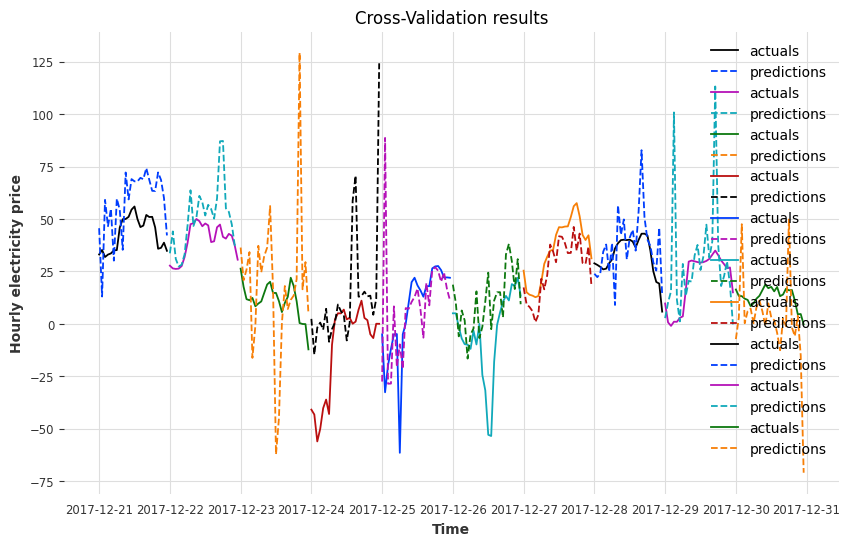

In [55]:
fig, ax = plt.subplots(figsize=(10,6))

for i in range(len(cv)):
    #outcome of the CV
    predictions = TimeSeries.pd_series(scaler1.inverse_transform(cv[i]))

    #actuals
    start = predictions.index.min()
    end = predictions.index.max()
    actuals = df.y[start:end]

    #plotting
    ax.plot(actuals,label = "actuals")
    ax.plot(predictions, label = "predictions", linestyle = "dashed")

ax.set_xlabel("Time")
ax.set_ylabel("Hourly electricity price")
ax.set_title("Cross-Validation results")
ax.legend()
plt.show()

# parameter tuning

In [75]:
from sklearn.model_selection import ParameterSampler

# Parameter grid (variable params)
param_grid = {
    "input_chunk_length": [48,96,172],
    "output_chunk_length": [24],
    "hidden_size": [8,16,24],
    "num_attention_heads": [2,4,6],
    "dropout": [0.1,0.2,0.3],
    "batch_size": [32,64,128],
    "lstm_layers": [1,2,4],
    "n_epochs": [5,10,20]
}

# number of combinations to try
n_iter = 10

param_list = list(ParameterSampler(param_grid, n_iter))
param_list2 = param_list
param_list_full = list(ParameterGrid(param_grid))
print(len(param_list))
print(len(param_list_full))

10
2187


In [72]:
fixed_params = {
    "use_static_covariates": True,
    "add_encoders": add_encoders,
    "pl_trainer_kwargs": {"accelerator": "cpu"}
}

for params in param_list:
    params.update(fixed_params)

In [73]:
# Check the fixed params
param_list[0]

{'output_chunk_length': 24,
 'num_attention_heads': 6,
 'n_epochs': 20,
 'lstm_layers': 1,
 'input_chunk_length': 172,
 'hidden_size': 16,
 'dropout': 0.3,
 'batch_size': 128,
 'use_static_covariates': True,
 'add_encoders': {'cyclic': {'future': ['hour',
    'day',
    'dayofweek',
    'week',
    'month']},
  'datetime_attribute': {'future': ['hour',
    'day',
    'dayofweek',
    'week',
    'month']},
  'position': {'past': ['relative'], 'future': ['relative']},
  'custom': {'past': [<function __main__.encode_year(idx)>],
   'future': [<function __main__.encode_year(idx)>]},
  'transformer': Scaler,
  'tz': 'cet'},
 'pl_trainer_kwargs': {'accelerator': 'cpu'}}

In [74]:
# Parameter tuning
rmse = []

for params in param_list:
    model = TFTModel(**params)

    #CV
    cv = model.historical_forecasts(
        series = y_transformed,
        past_covariates = past_covariates_transformed,
        future_covariates = future_covariates_transformed,
        forecast_horizon = forecasting_horizon,
        start = df.shape[0] - 10 * forecasting_horizon,
        retrain = True,
        stride = forecasting_horizon, #The number of time steps between two consecutive predictions.
        last_points_only = False
    )

    # CV results
    rmse_cv = []
    for i in range(len(cv)):
        #outcome of the CV
        predictions = TimeSeries.pd_series(scaler1.inverse_transform(cv[i]))
    
        #actuals
        start = predictions.index.min()
        end = predictions.index.max()
        actuals = df.y[start:end]
    
        #compute error
        error_cv = root_mean_squared_error(actuals,predictions)
        rmse_cv.append(error_cv)

    rmse.append(np.mean(rmse_cv))
    print(f"Tested parameters: {params} => RMSE {np.mean(rmse_cv)}")

`enable_optimization=True` is ignored because `retrain` is not `False` or `0`. To hide this warning, set `show_warnings=False` or `enable_optimization=False`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 17.2 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 13.7 K | t

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=20` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 17.2 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 13.7 K | t

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=20` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 17.2 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 13.7 K | t

...

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=10` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 9.9 K  | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 7.9 K  | t

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=10` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Tested parameters: {'output_chunk_length': 24, 'num_attention_heads': 2, 'n_epochs': 10, 'lstm_layers': 2, 'input_chunk_length': 172, 'hidden_size': 8, 'dropout': 0.3, 'batch_size': 32, 'use_static_covariates': True, 'add_encoders': {'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'position': {'past': ['relative'], 'future': ['relative']}, 'custom': {'past': [<function encode_year at 0x000002B6EA0A34C0>], 'future': [<function encode_year at 0x000002B6EA0A34C0>]}, 'transformer': Scaler, 'tz': 'cet'}, 'pl_trainer_kwargs': {'accelerator': 'cpu'}} => RMSE 30.039397331046104


In [76]:
# Check the best results
results_df = pd.DataFrame(param_list2)
results_df["rmse"] = rmse
results_df.sort_values(by = "rmse")

,output_chunk_length,num_attention_heads,n_epochs,lstm_layers,input_chunk_length,hidden_size,dropout,batch_size,rmse
5,24,6,5,2,96,16,0.2,32,15.202928
8,24,4,20,1,48,16,0.2,64,19.784753
2,24,2,20,2,96,16,0.1,64,26.151884
7,24,6,20,1,172,8,0.1,128,26.214688
6,24,4,5,1,172,8,0.1,32,26.775415
0,24,2,10,2,48,16,0.2,128,28.986888
9,24,6,20,1,48,16,0.1,128,30.039397
3,24,6,20,2,48,8,0.2,32,30.622029
1,24,4,10,2,48,16,0.3,32,32.416992
4,24,2,5,1,172,16,0.1,32,35.156973


In [77]:
# Export the params
best_params = results_df[results_df["rmse"] == results_df["rmse"].min()]
best_params.to_csv("best_params_freek.csv")

# Predict the future

In [83]:
best_params = pd.read_csv("best_params_freek.csv", index_col=0).drop(columns = "rmse")
best_params_dict = best_params.squeeze().to_dict()
best_params_dict

{'output_chunk_length': 24.0,
 'num_attention_heads': 6.0,
 'n_epochs': 5.0,
 'lstm_layers': 2.0,
 'input_chunk_length': 96.0,
 'hidden_size': 16.0,
 'dropout': 0.2,
 'batch_size': 32.0}

In [87]:
# Convert float parameters to integers
int_params = ["input_chunk_length","output_chunk_length","hidden_size",
              "num_attention_heads","batch_size","lstm_layers","n_epochs"]
for key in int_params:
    best_params_dict[key] = int(best_params_dict[key])

best_params_dict.update(fixed_params)
best_params_dict

{'output_chunk_length': 24,
 'num_attention_heads': 6,
 'n_epochs': 5,
 'lstm_layers': 2,
 'input_chunk_length': 96,
 'hidden_size': 16,
 'dropout': 0.2,
 'batch_size': 32,
 'use_static_covariates': True,
 'add_encoders': {'cyclic': {'future': ['hour',
    'day',
    'dayofweek',
    'week',
    'month']},
  'datetime_attribute': {'future': ['hour',
    'day',
    'dayofweek',
    'week',
    'month']},
  'position': {'past': ['relative'], 'future': ['relative']},
  'custom': {'past': [<function __main__.encode_year(idx)>],
   'future': [<function __main__.encode_year(idx)>]},
  'transformer': Scaler,
  'tz': 'cet'},
 'pl_trainer_kwargs': {'accelerator': 'cpu'}}

In [88]:
# build the tuned TFT model
tuned_model = TFTModel(**best_params_dict)
tuned_model.fit(y_transformed, past_covariates=
                past_covariates_transformed,
                future_covariates=future_covariates_transformed)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 17.2 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 13.7 K | train
6  | static_context_grn                | _GatedResidualNetwork            | 1.1 K  | train
7  | static_context_hidden_encoder_grn | _GatedResidualNetwork 

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=5` reached.


TFTModel(output_chunk_shift=0, hidden_size=16, lstm_layers=2, num_attention_heads=6, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.2, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=False, loss_fn=None, likelihood=None, norm_type=LayerNorm, use_static_covariates=True, output_chunk_length=24, n_epochs=5, input_chunk_length=96, batch_size=32, add_encoders={'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'position': {'past': ['relative'], 'future': ['relative']}, 'custom': {'past': [<function encode_year at 0x000002B6EA0A34C0>], 'future': [<function encode_year at 0x000002B6EA0A34C0>]}, 'transformer': Scaler, 'tz': 'cet'}, pl_trainer_kwargs={'accelerator': 'cpu'})

# Forecast the future

In [94]:
# tuned model to predict
forecast = tuned_model.predict(n = forecasting_horizon,
                               series = y_transformed,
                               past_covariates=past_covariates_transformed,
                               future_covariates=future_covariates_transformed)
forecast = TimeSeries.pd_series(scaler1.inverse_transform(forecast)).rename("TFT")
forecast

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |                                                                                    | 0/? [00:00<…

ds
2017-12-31 00:00:00   -30.553528
2017-12-31 01:00:00   -34.449772
2017-12-31 02:00:00   -70.449452
2017-12-31 03:00:00   -18.789228
2017-12-31 04:00:00   -16.815641
2017-12-31 05:00:00   -10.852505
2017-12-31 06:00:00   -14.216523
2017-12-31 07:00:00   -13.890547
2017-12-31 08:00:00    -4.340948
2017-12-31 09:00:00   -12.245485
2017-12-31 10:00:00     4.118778
2017-12-31 11:00:00    18.466517
2017-12-31 12:00:00    -4.869862
2017-12-31 13:00:00    -8.645816
2017-12-31 14:00:00   -26.296620
2017-12-31 15:00:00   -87.378874
2017-12-31 16:00:00   -11.301260
2017-12-31 17:00:00   -19.702086
2017-12-31 18:00:00   -15.915784
2017-12-31 19:00:00   -11.402946
2017-12-31 20:00:00   -15.183687
2017-12-31 21:00:00   -19.328446
2017-12-31 22:00:00   -88.670439
2017-12-31 23:00:00     0.304191
Freq: H, Name: TFT, dtype: float64

[]

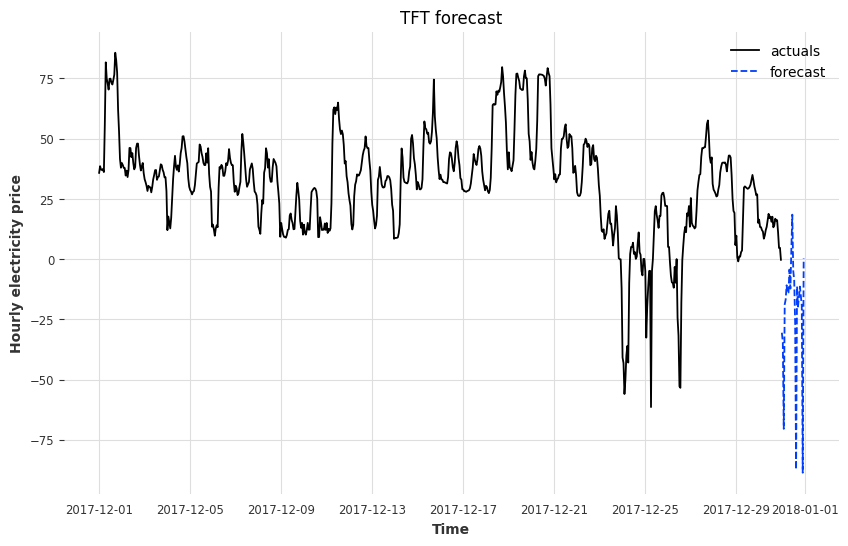

In [96]:
# plot the forecast
fig,ax = plt.subplots(figsize = (10,6))
ax.plot(df.y["2017-12":], label = "actuals")
ax.plot(forecast, label = "forecast", linestyle = "dashed")
ax.set_xlabel("Time")
ax.set_ylabel("Hourly electricity price")
ax.set_title("TFT forecast")
ax.legend()
ax.plot()

In [102]:
from darts.explainability import TFTExplainer

# build the explainer
explainer = TFTExplainer(tuned_model)
explain_result = explainer.explain()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |                                                                                    | 0/? [00:00<…

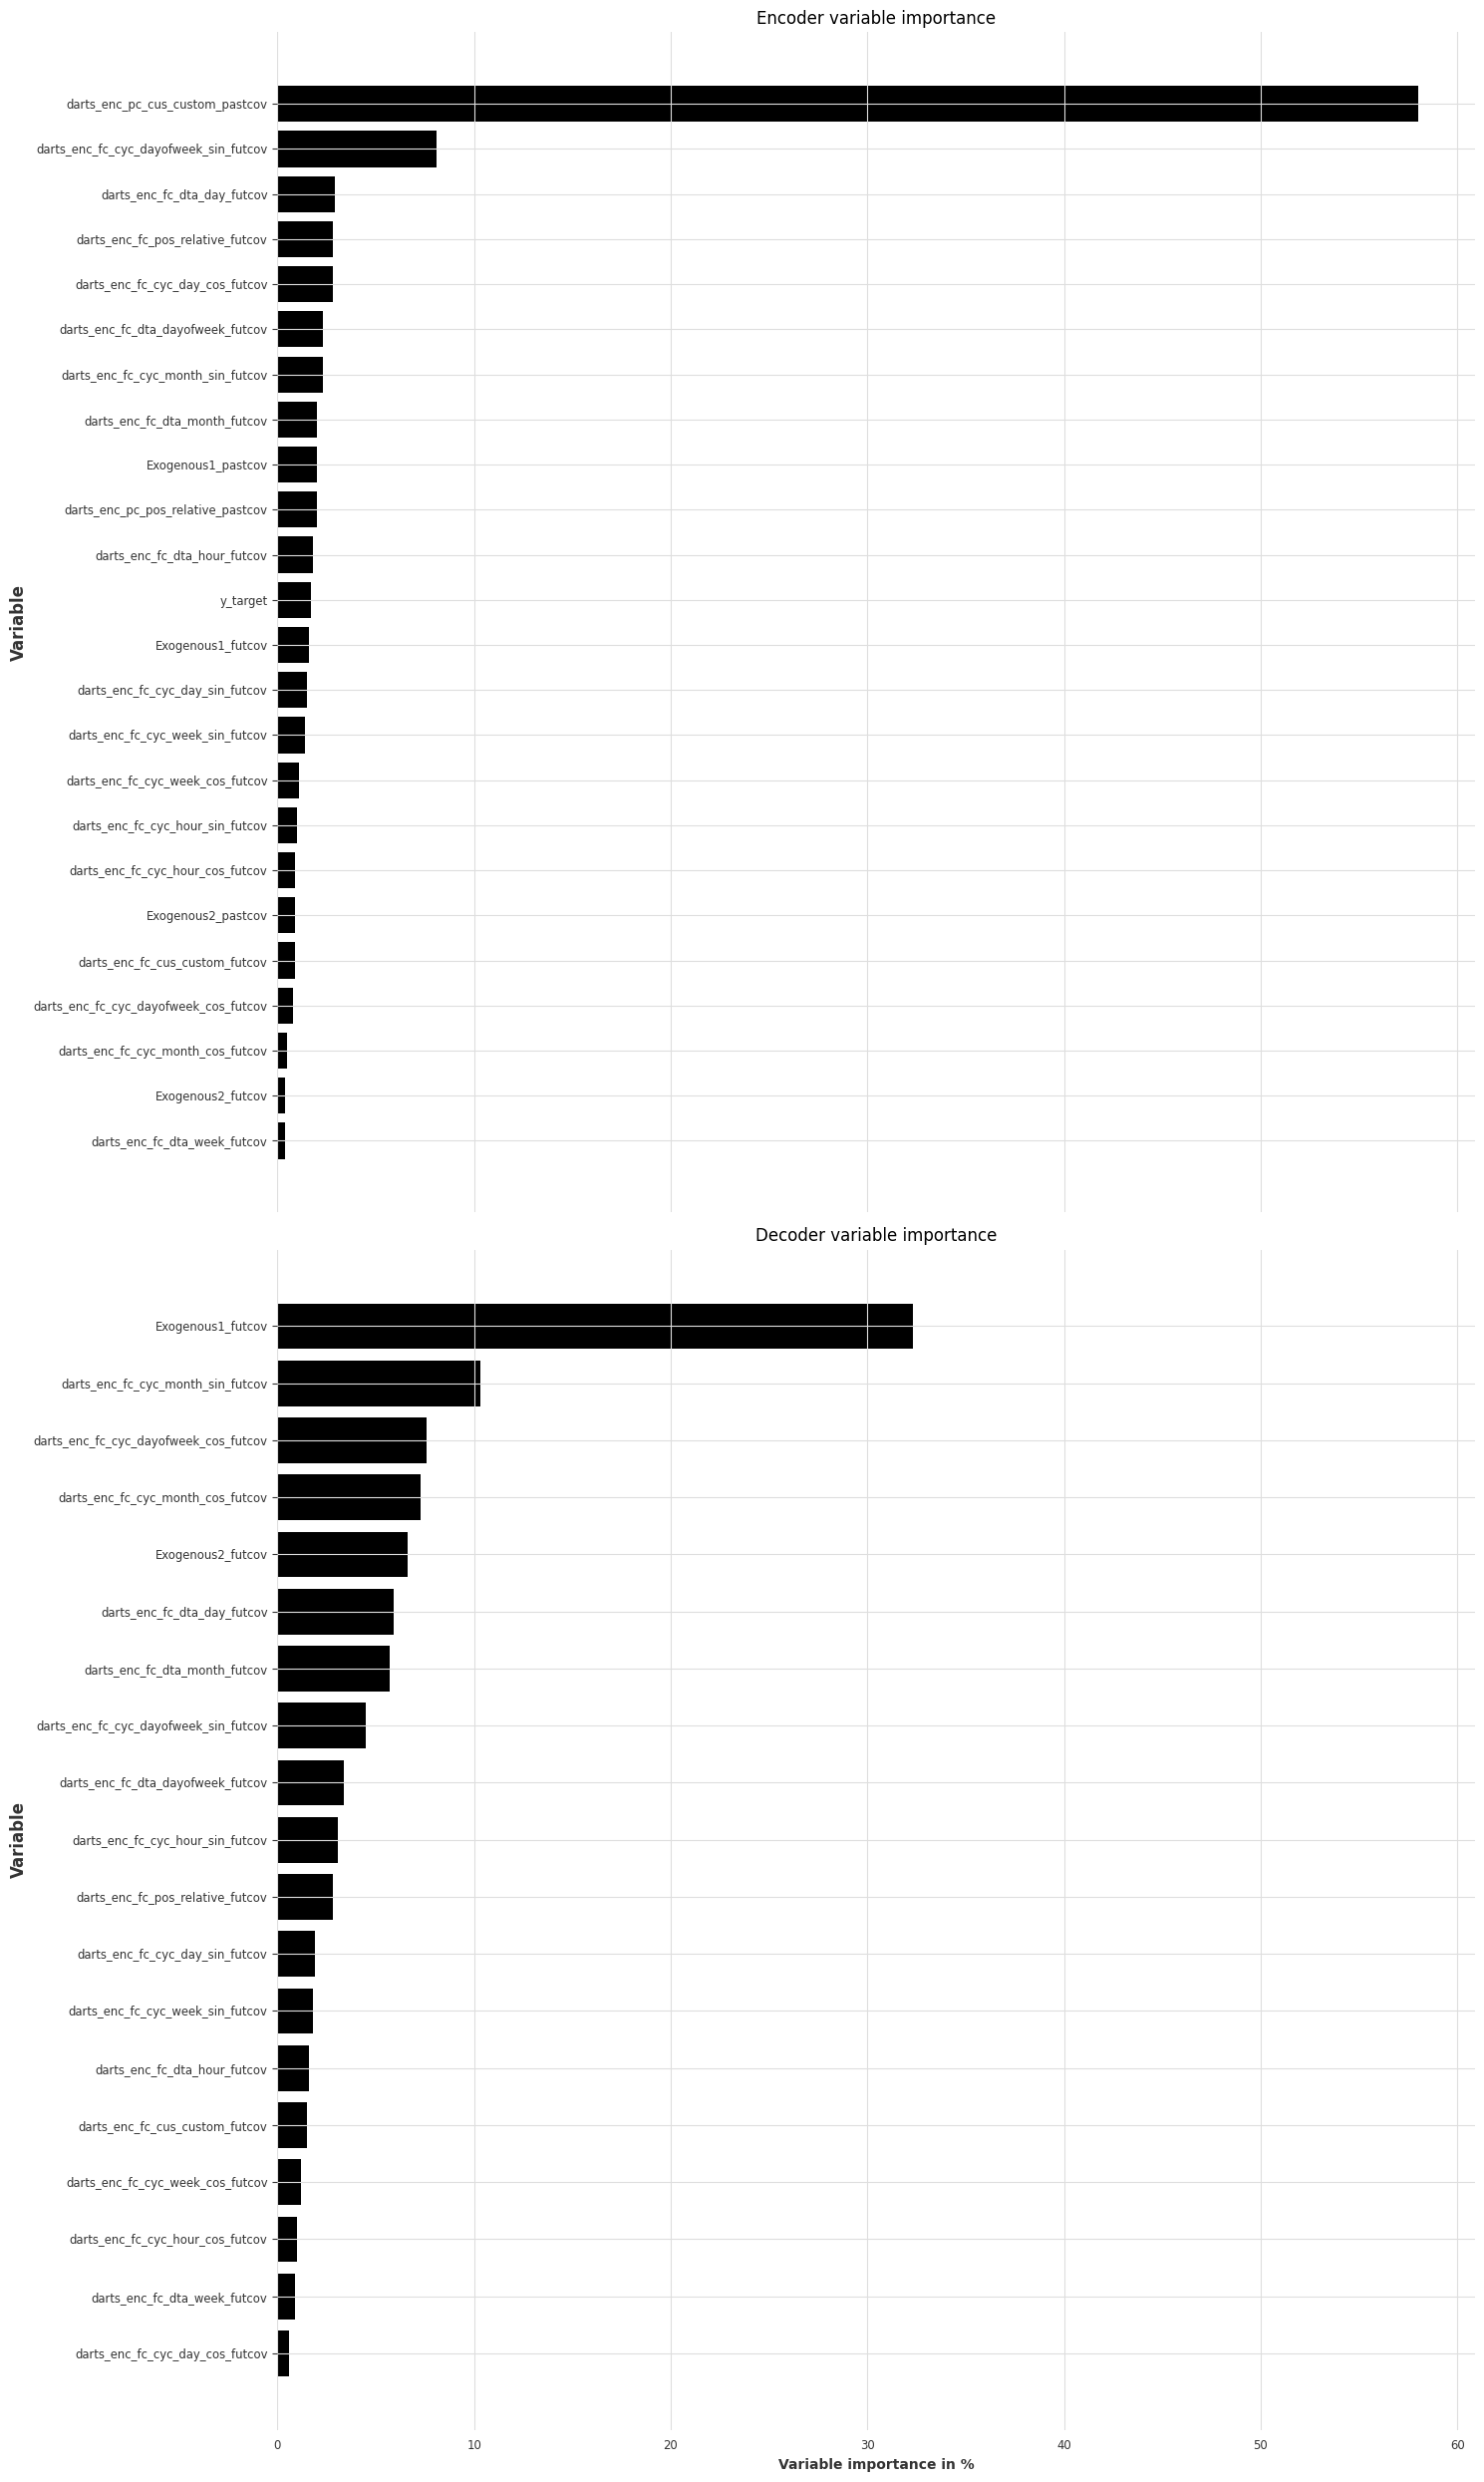

In [106]:
#plotting the variable importance
explainer.plot_variable_selection(explain_result, fig_size=(15,25))

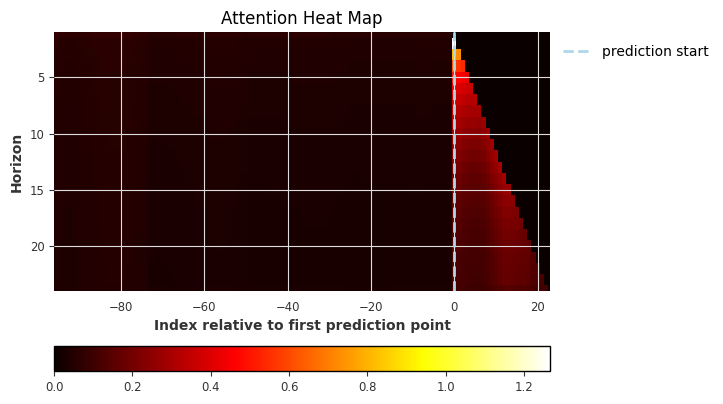

<Axes: title={'center': 'Attention Heat Map'}, xlabel='Index relative to first prediction point', ylabel='Horizon'>

In [107]:
# Attention mechanisms
explainer.plot_attention(explain_result, plot_type="heatmap")

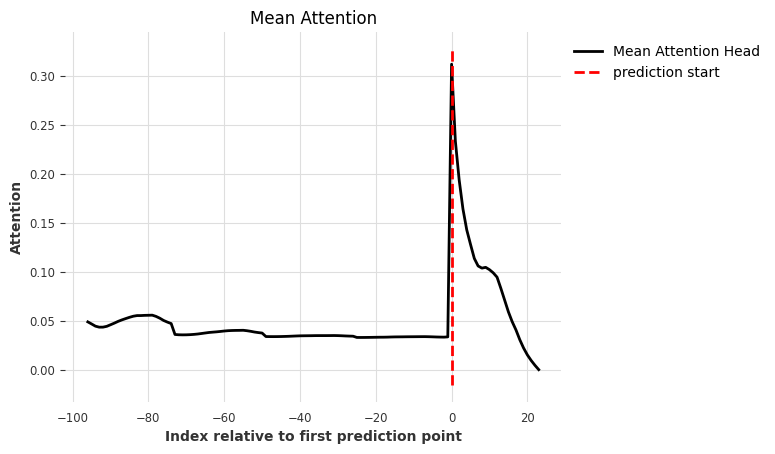

<Axes: title={'center': 'Mean Attention'}, xlabel='Index relative to first prediction point', ylabel='Attention'>

In [109]:
# Attention mechanisms
explainer.plot_attention(explain_result, plot_type="time")